In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, classification_report, accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, BatchNormalization, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
import tensorflow as tf
import warnings

# Konfigurasi agar hasil reproducible (tetap sama setiap di-run)
warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)

print("="*50)
print("🚀 SYSTEM READY: BASELINE MODEL (NO INDICATORS)")
print("="*50)

🚀 SYSTEM READY: BASELINE MODEL (NO INDICATORS)


In [2]:
# Konfigurasi Data
TICKER = 'NVDA'       
START_DATE = '2018-01-01'  # Tetap 2018 sesuai analisis (Structural Break)
END_DATE = '2024-12-31'

print(f"📥 Mengunduh data {TICKER}...")
df = yf.download(TICKER, start=START_DATE, end=END_DATE, progress=False)

# Handling MultiIndex kolom (jika ada update yfinance terbaru)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

print(f"✅ Data berhasil diunduh. Dimensi: {df.shape}")
df.head()

📥 Mengunduh data NVDA...


✅ Data berhasil diunduh. Dimensi: (1760, 5)


Price,Close,High,Low,Open,Volume
Date,,,,,
2018-01-02,4.928533,4.932242,4.808627,4.840272,355616000
2018-01-03,5.252899,5.283308,5.037314,5.045967,914704000
2018-01-04,5.280588,5.390853,5.258337,5.334237,583268000
2018-01-05,5.325336,5.362668,5.218533,5.295422,580124000
2018-01-08,5.488510,5.562679,5.403957,5.448953,881216000


In [3]:
def prepare_basic_data(df):
    df = df.copy()
    
    # 1. Basic Log Return (Wajib ada karena ini adalah Target Prediksi)
    # Log Return membuat data menjadi stasioner, penting untuk LSTM
    df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))
    
    # 2. Volume Log (Basic Feature)
    # Kita tetap pakai Log Volume agar range angkanya tidak jomplang dengan Log Return
    df['Volume_Log'] = np.log1p(df['Volume'])
    
    # Hapus baris NaN akibat shift
    return df.dropna()

df_processed = prepare_basic_data(df)
print(f"✅ Preprocessing Data Mentah Selesai. Total baris: {len(df_processed)}")
df_processed[['Close', 'Log_Return', 'Volume', 'Volume_Log']].head()

✅ Preprocessing Data Mentah Selesai. Total baris: 1759


Price,Close,Log_Return,Volume,Volume_Log
Date,,,,
2018-01-03,5.252899,0.063739,914704000,20.634111
2018-01-04,5.280588,0.005257,583268000,20.184157
2018-01-05,5.325336,0.008439,580124000,20.178752
2018-01-08,5.488510,0.030181,881216000,20.596813
2018-01-09,5.487027,-0.000270,497000000,20.024101


In [4]:
# Target Prediction (Log Return Besok)
df_processed['Target'] = df_processed['Log_Return'].shift(-1)
df_processed = df_processed.dropna()

# ---------------------------------------------------------
# STRATEGI: RAW DATA ONLY (MODEL B)
# Kita hanya menggunakan 2 Fitur Dasar:
# 1. Log_Return (Representasi Harga Hari Ini)
# 2. Volume_Log (Representasi Aktivitas Pasar)
# TIDAK ADA ATR, RSI, atau Volatility Rolling.
# ---------------------------------------------------------
feature_cols = [
    'Log_Return', 
    'Volume_Log'
]

X = df_processed[feature_cols].values
y = df_processed[['Target']].values

print(f"📌 Fitur Terpilih (Baseline - {len(feature_cols)} Fitur): {feature_cols}")
print("✅ Data Siap untuk Training (Tanpa Indikator Teknikal)")

📌 Fitur Terpilih (Baseline - 2 Fitur): ['Log_Return', 'Volume_Log']
✅ Data Siap untuk Training (Tanpa Indikator Teknikal)


In [5]:
# Split Data (80% Train, 20% Test)
split_idx = int(len(X) * 0.8)

X_train_raw = X[:split_idx]
y_train_raw = y[:split_idx]
X_test_raw = X[split_idx:]
y_test_raw = y[split_idx:]

# Scaling (Fit hanya di Train, Transform di Test)
# X menggunakan StandardScaler (karena distribusi return mirip lonceng/normal)
# y menggunakan MinMaxScaler (-1 sampai 1) agar sesuai range aktivasi Tanh pada LSTM
scaler_X = StandardScaler()
scaler_y = MinMaxScaler(feature_range=(-1, 1))

X_train_scaled = scaler_X.fit_transform(X_train_raw)
y_train_scaled = scaler_y.fit_transform(y_train_raw)

X_test_scaled = scaler_X.transform(X_test_raw)
y_test_scaled = scaler_y.transform(y_test_raw)

print("✅ Splitting & Scaling selesai (Aman dari Data Leakage)")
print(f"   Train size: {len(X_train_scaled)} | Test size: {len(X_test_scaled)}")

✅ Splitting & Scaling selesai (Aman dari Data Leakage)
   Train size: 1406 | Test size: 352


In [6]:
def create_sequences(X, y, time_steps=60):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

TIME_STEPS = 60

X_train, y_train = create_sequences(X_train_scaled, y_train_scaled, TIME_STEPS)
X_test, y_test = create_sequences(X_test_scaled, y_test_scaled, TIME_STEPS)

print(f"📦 Sequence terbentuk (Window: {TIME_STEPS} hari)")
print(f"   Input Shape: {X_train.shape} (Sampel, TimeSteps, Fitur)")
# Note: Fitur harusnya bernilai 2

📦 Sequence terbentuk (Window: 60 hari)
   Input Shape: (1346, 60, 2) (Sampel, TimeSteps, Fitur)


In [7]:
# Kita menggunakan arsitektur yang 100% sama dengan Model A agar adil.
# Perbedaannya hanya di Input Layer yang otomatis menyesuaikan jumlah fitur (2 vs 5).

model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    
    # Layer 1: Bidirectional LSTM
    Bidirectional(LSTM(64, return_sequences=True, kernel_regularizer=l2(0.001))),
    BatchNormalization(),
    Dropout(0.3),
    
    # Layer 2: LSTM Biasa
    LSTM(64, return_sequences=False, kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.3),
    
    # Output Layer
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 60, 128)        │        34,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 60, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 86,593 (338.25 KB)

 Trainable params: 86,209 (336.75 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - loss: 1.6153 - mae: 0.9189 - val_loss: 0.2559 - val_mae: 0.1494 - learning_rate: 0.0010
Epoch 2/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.8002 - mae: 0.5914 - val_loss: 0.2546 - val_mae: 0.1489 - learning_rate: 0.0010
Epoch 3/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.5802 - mae: 0.4732 - val_loss: 0.2574 - val_mae: 0.1639 - learning_rate: 0.0010
Epoch 4/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.4967 - mae: 0.4116 - val_loss: 0.2614 - val_mae: 0.1787 - learning_rate: 0.0010
Epoch 5/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.4648 - mae: 0.3968 - val_loss: 0.2577 - val_mae: 0.1745 - learning_rate: 0.0010
Epoch 6/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.4051 - mae: 0.3396 - val_loss: 0.2516 - val_mae: 0.1717 - learning_rate: 0.0010
Epoch 7/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.3653 - mae: 0.3164 - val_loss: 0.2519 - val_mae: 0.1787 - learning_rate: 0.0010
Epoch 

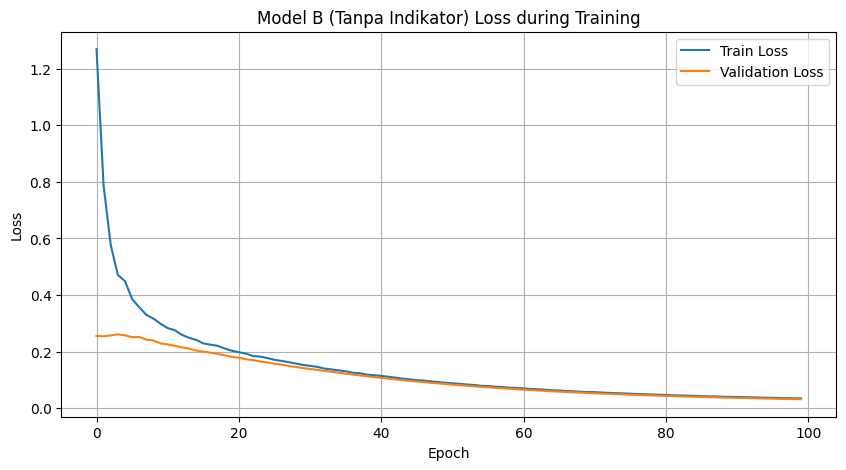

In [8]:
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Plot Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model B (Tanpa Indikator) Loss during Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

📊 HASIL EVALUASI MODEL B (TANPA INDIKATOR)
RMSE : 3.2615
MAE  : 2.3483
MAPE : 2.32%
Directional Accuracy: 57.19%


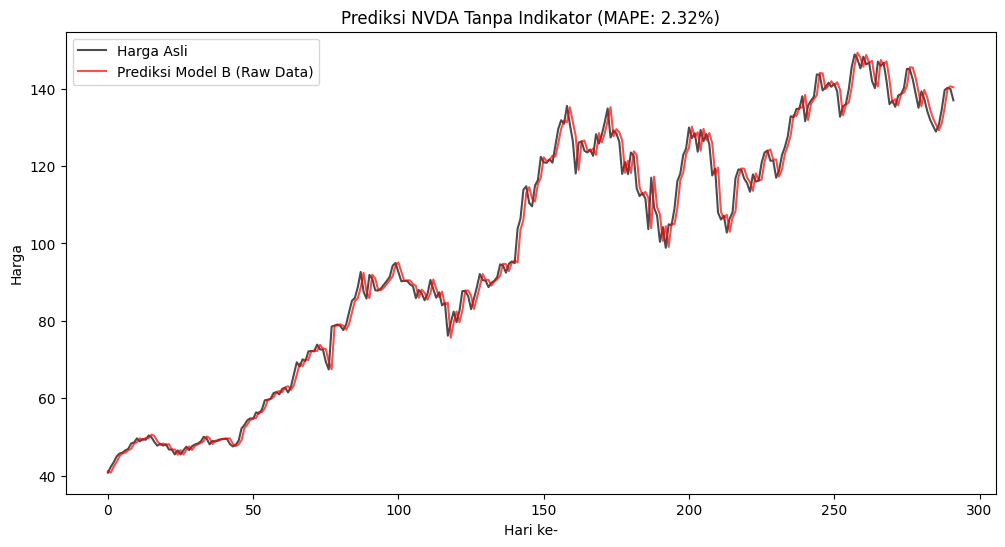

In [9]:
# Prediksi
y_pred_scaled = model.predict(X_test, verbose=0)

# Inverse Transform (Kembalikan ke skala Log Return asli)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_actual = scaler_y.inverse_transform(y_test)

# Rekonstruksi ke Harga Asli (Rupiah/Dollar)
# Rumus: Harga_Esok = Harga_Hari_Ini * exp(Log_Return_Prediksi)
test_start_idx = split_idx + TIME_STEPS
base_prices = df_processed['Close'].iloc[test_start_idx-1 : -1].values

predicted_prices = base_prices * np.exp(y_pred.flatten())
actual_prices = df_processed['Close'].iloc[test_start_idx:].values[:len(predicted_prices)]

# Metrik Evaluasi
rmse = np.sqrt(mean_squared_error(actual_prices, predicted_prices))
mae = mean_absolute_error(actual_prices, predicted_prices)
mape = np.mean(np.abs((actual_prices - predicted_prices) / actual_prices)) * 100

print("="*40)
print("📊 HASIL EVALUASI MODEL B (TANPA INDIKATOR)")
print("="*40)
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MAPE : {mape:.2f}%")

# Directional Accuracy
pred_direction = (y_pred.flatten() > 0).astype(int)
actual_direction = (y_actual.flatten() > 0).astype(int)
accuracy = accuracy_score(actual_direction, pred_direction)
print(f"Directional Accuracy: {accuracy*100:.2f}%")

# Plot Perbandingan Harga
plt.figure(figsize=(12, 6))
plt.plot(actual_prices, label='Harga Asli', color='black', alpha=0.7)
plt.plot(predicted_prices, label='Prediksi Model B (Raw Data)', color='red', alpha=0.7)
plt.title(f'Prediksi NVDA Tanpa Indikator (MAPE: {mape:.2f}%)')
plt.xlabel('Hari ke-')
plt.ylabel('Harga')
plt.legend()
plt.show()

In [11]:
# ==========================================
# SAVE MODEL & COMPONENTS (WITHOUT INDICATORS)
# ==========================================
import pickle
import os

# Buat folder untuk simpan model
os.makedirs('models', exist_ok=True)

print("Menyimpan model TANPA indikator...")

# 1. Save Model LSTM
model.save('models/lstm_without_indicators.keras')
print("Model saved: lstm_without_indicators.keras")

# 2. Save Scalers
with open('models/scaler_X_without_indicators.pkl', 'wb') as f:
    pickle.dump(scaler_X, f)
with open('models/scaler_y_without_indicators.pkl', 'wb') as f:
    pickle.dump(scaler_y, f)
print("Scalers saved")

# 3. Save Results & Metrics
results_without_indicators = {
    'actual_prices': actual_prices,
    'predicted_prices': predicted_prices,
    'rmse': rmse,
    'mae': mae,
    'mape': mape,
    'accuracy': accuracy,
    'feature_cols': feature_cols,
    'pred_direction': pred_direction,
    'actual_direction': actual_direction,
    'history': history.history,
    'TIME_STEPS': TIME_STEPS,
    'ticker': TICKER,
    'split_idx': split_idx
}

with open('models/results_without_indicators.pkl', 'wb') as f:
    pickle.dump(results_without_indicators, f)
print("Results saved")

print("\nSEMUA KOMPONEN BERHASIL DISAVE!")
print("File tersimpan di folder 'models/':")
print("   - lstm_without_indicators.keras")
print("   - scaler_X_without_indicators.pkl")
print("   - scaler_y_without_indicators.pkl")
print("   - results_without_indicators.pkl")

Menyimpan model TANPA indikator...
Model saved: lstm_without_indicators.keras
Scalers saved
Results saved

SEMUA KOMPONEN BERHASIL DISAVE!
File tersimpan di folder 'models/':
   - lstm_without_indicators.keras
   - scaler_X_without_indicators.pkl
   - scaler_y_without_indicators.pkl
   - results_without_indicators.pkl
